# 05 Forecasting Baseline

This notebook builds valid baseline models for Part 3. It uses only `sales.csv` as the training target source, evaluates validation forecasts with MAE, RMSE, and R2, and selects the best baseline as the benchmark for notebook 06.

The validation split is time-based. No external data and no test-period target values are used.


## 1. Setup


In [1]:
.libPaths(c(normalizePath("r_libs/4.4", winslash = "/", mustWork = TRUE), .libPaths()))

library(dplyr)
library(tidyr)
library(lubridate)
library(ggplot2)
library(scales)
library(tsibble)
library(fable)
library(feasts)
library(forecast)

options(scipen = 999)
theme_minimal(base_size = 11) |> theme_set()

project_root <- normalizePath(getwd(), winslash = "/", mustWork = TRUE)
while (!dir.exists(file.path(project_root, "dataset")) && dirname(project_root) != project_root) {
  project_root <- dirname(project_root)
}

data_dir <- file.path(project_root, "dataset")
artifact_dir <- file.path(project_root, "artifacts", "forecast_baseline")
chart_dir <- file.path(artifact_dir, "charts")
dir.create(chart_dir, recursive = TRUE, showWarnings = FALSE)

set.seed(2026)

print(project_root)
print(artifact_dir)



Attaching package: 'dplyr'




The following objects are masked from 'package:stats':

    filter, lag




The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union





Attaching package: 'lubridate'




The following objects are masked from 'package:base':

    date, intersect, setdiff, union




...

The following object is masked from 'package:lubridate':

    interval




The following objects are masked from 'package:base':

    intersect, setdiff, union




Loading required package: fabletools



[1] "C:/Users/admin/OneDrive - National Economics University/Documents/NCKH/DATATHON/Neu_BRT_Datathon"


[1] "C:/Users/admin/OneDrive - National Economics University/Documents/NCKH/DATATHON/Neu_BRT_Datathon/artifacts/forecast_baseline"


## 2. Load `sales.csv` And Sort By Date


In [2]:
sales_raw <- read.csv(file.path(data_dir, "sales.csv"), stringsAsFactors = FALSE) |>
  mutate(Date = as.Date(Date)) |>
  arrange(Date)

sales_daily <- sales_raw |>
  transmute(
    Date,
    Revenue = as.numeric(Revenue),
    COGS = as.numeric(COGS)
  )

summary_table <- tibble::tibble(
  rows = nrow(sales_daily),
  min_date = min(sales_daily$Date),
  max_date = max(sales_daily$Date),
  total_revenue = sum(sales_daily$Revenue, na.rm = TRUE),
  total_cogs = sum(sales_daily$COGS, na.rm = TRUE)
)

summary_table


rows,min_date,max_date,total_revenue,total_cogs
<int>,<date>,<date>,<dbl>,<dbl>
3833,2012-07-04,2022-12-31,16430476586,14163450519


## 3. Check Missing Dates And Basic Time-Series Structure


In [3]:
full_calendar <- tibble::tibble(Date = seq.Date(min(sales_daily$Date), max(sales_daily$Date), by = "day"))

missing_dates <- full_calendar |>
  anti_join(sales_daily, by = "Date")

duplicate_dates <- sales_daily |>
  count(Date, name = "records") |>
  filter(records > 1)

date_quality <- tibble::tibble(
  expected_days = nrow(full_calendar),
  observed_days = nrow(sales_daily),
  missing_days = nrow(missing_dates),
  duplicate_dates = nrow(duplicate_dates)
)

date_quality
missing_dates |> head(20)


expected_days,observed_days,missing_days,duplicate_dates
<int>,<int>,<int>,<int>
3833,3833,0,0


Date
<date>


## 4. Basic Trend And Seasonality Check

This is a light diagnostic step. The goal is to understand the target before modeling, not to engineer complex features in the baseline notebook.


In [4]:
sales_features <- sales_daily |>
  mutate(
    year = year(Date),
    month = month(Date),
    month_label = month(Date, label = TRUE, abbr = TRUE),
    weekday = wday(Date, label = TRUE, abbr = TRUE, week_start = 1),
    time_index = row_number()
  )

monthly_revenue <- sales_features |>
  mutate(month_date = floor_date(Date, "month")) |>
  group_by(month_date) |>
  summarise(revenue = sum(Revenue, na.rm = TRUE), .groups = "drop")

seasonality_month <- sales_features |>
  group_by(month, month_label) |>
  summarise(avg_daily_revenue = mean(Revenue, na.rm = TRUE), .groups = "drop") |>
  arrange(desc(avg_daily_revenue))

seasonality_weekday <- sales_features |>
  group_by(weekday) |>
  summarise(avg_daily_revenue = mean(Revenue, na.rm = TRUE), .groups = "drop") |>
  arrange(desc(avg_daily_revenue))

seasonality_month
seasonality_weekday


month,month_label,avg_daily_revenue
<dbl>,<ord>,<dbl>
5,May,6575416
4,Apr,6532952
6,Jun,6427109
3,Mar,4928185
7,Jul,4659789
8,Aug,4441193
9,Sep,3797826
2,Feb,3480801
10,Oct,3302725


weekday,avg_daily_revenue
<ord>,<dbl>
Wed,4680065
Thu,4523044
Tue,4465103
Mon,4311035
Sun,4073854
Fri,4046390
Sat,3906581


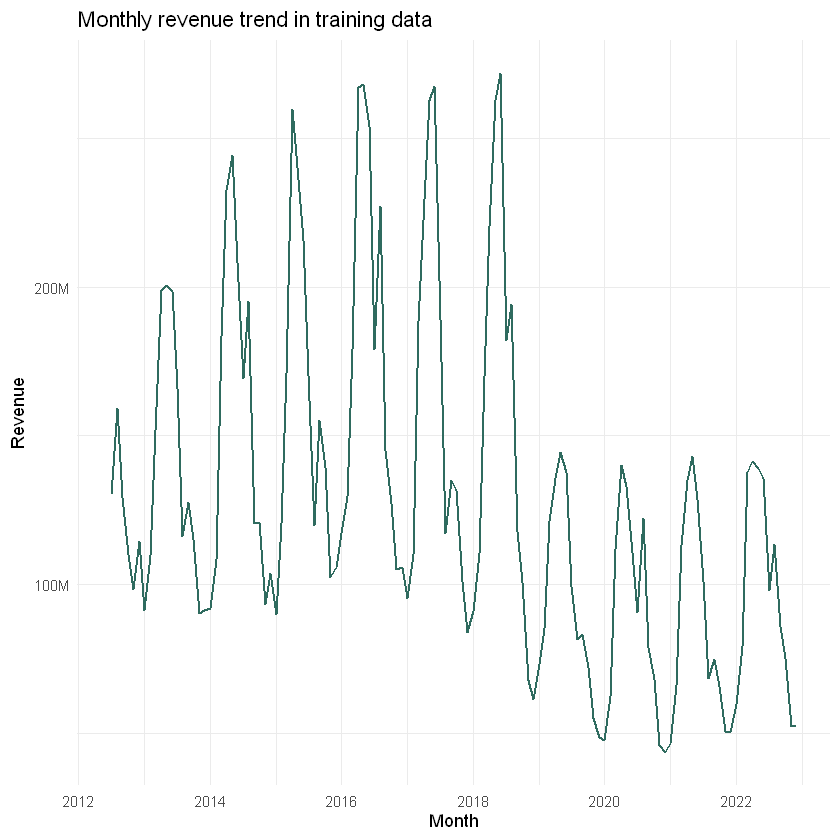

In [5]:
p_trend <- ggplot(monthly_revenue, aes(x = month_date, y = revenue)) +
  geom_line(color = "#2F6B5F", linewidth = 0.7) +
  scale_y_continuous(labels = label_number(scale_cut = cut_short_scale())) +
  labs(
    title = "Monthly revenue trend in training data",
    x = "Month",
    y = "Revenue"
  )

p_trend
ggsave(file.path(chart_dir, "baseline_01_monthly_trend.png"), p_trend, width = 9, height = 5, dpi = 160)


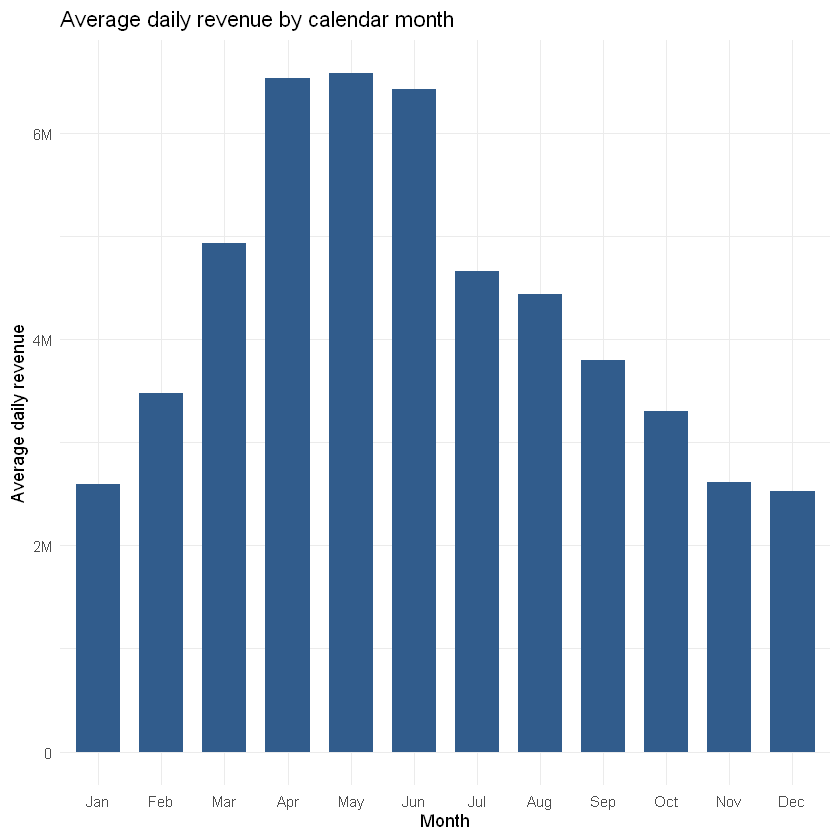

In [6]:
p_seasonality <- ggplot(seasonality_month, aes(x = reorder(month_label, month), y = avg_daily_revenue)) +
  geom_col(fill = "#315C8C", width = 0.7) +
  scale_y_continuous(labels = label_number(scale_cut = cut_short_scale())) +
  labs(
    title = "Average daily revenue by calendar month",
    x = "Month",
    y = "Average daily revenue"
  )

p_seasonality
ggsave(file.path(chart_dir, "baseline_02_month_seasonality.png"), p_seasonality, width = 8, height = 5, dpi = 160)


## 5. Time-Based Train/Validation Split

The last 365 observed days are used as validation. This preserves chronological order and avoids leakage from future values into model fitting.


In [7]:
validation_days <- 365
split_date <- max(sales_daily$Date) - days(validation_days)

train_data <- sales_daily |> filter(Date <= split_date)
valid_data <- sales_daily |> filter(Date > split_date)

split_summary <- tibble::tibble(
  split_date = split_date,
  train_start = min(train_data$Date),
  train_end = max(train_data$Date),
  train_rows = nrow(train_data),
  validation_start = min(valid_data$Date),
  validation_end = max(valid_data$Date),
  validation_rows = nrow(valid_data)
)

split_summary


split_date,train_start,train_end,train_rows,validation_start,validation_end,validation_rows
<date>,<date>,<date>,<int>,<date>,<date>,<int>
2021-12-31,2012-07-04,2021-12-31,3468,2022-01-01,2022-12-31,365


## 6. Baseline Models


In [8]:
make_metrics <- function(actual, forecast) {
  residual <- actual - forecast
  mae <- mean(abs(residual), na.rm = TRUE)
  rmse <- sqrt(mean(residual^2, na.rm = TRUE))
  sse <- sum(residual^2, na.rm = TRUE)
  sst <- sum((actual - mean(actual, na.rm = TRUE))^2, na.rm = TRUE)
  r2 <- 1 - sse / sst
  tibble::tibble(MAE = mae, RMSE = rmse, R2 = r2)
}

h <- nrow(valid_data)
train_revenue <- train_data$Revenue

regression_train <- train_data |>
  mutate(
    time_index = as.numeric(Date - min(train_data$Date)) + 1,
    month = factor(month(Date)),
    weekday = factor(wday(Date, week_start = 1))
  )

regression_valid <- valid_data |>
  mutate(
    time_index = as.numeric(Date - min(train_data$Date)) + 1,
    month = factor(month(Date), levels = levels(regression_train$month)),
    weekday = factor(wday(Date, week_start = 1), levels = levels(regression_train$weekday))
  )

lm_fit <- lm(Revenue ~ time_index + month + weekday, data = regression_train)

baseline_predictions <- valid_data |>
  transmute(Date, actual = Revenue) |>
  mutate(
    naive = tail(train_revenue, 1),
    moving_average_7 = mean(tail(train_revenue, 7), na.rm = TRUE),
    moving_average_30 = mean(tail(train_revenue, 30), na.rm = TRUE),
    seasonal_naive_7 = train_data$Revenue[match(Date - days(7), train_data$Date)],
    seasonal_naive_30 = train_data$Revenue[match(Date - days(30), train_data$Date)],
    linear_time_features = as.numeric(predict(lm_fit, newdata = regression_valid))
  )

baseline_predictions <- baseline_predictions |>
  mutate(
    seasonal_naive_7 = ifelse(is.na(seasonal_naive_7), naive, seasonal_naive_7),
    seasonal_naive_30 = ifelse(is.na(seasonal_naive_30), moving_average_30, seasonal_naive_30)
  )

baseline_predictions |> head()


,Date,actual,naive,moving_average_7,moving_average_30,seasonal_naive_7,seasonal_naive_30,linear_time_features
,<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,2022-01-01,2932155.5,3041204,2323897,1617411,1120987,1911471.0,920049.9
2,2022-01-02,2361965.0,3041204,2323897,1617411,1317218,586748.2,1082089.3
3,2022-01-03,545563.7,3041204,2323897,1617411,1025038,819389.6,1339643.3
4,2022-01-04,1242319.4,3041204,2323897,1617411,1855064,1101768.1,1504839.2
5,2022-01-05,809977.6,3041204,2323897,1617411,4065185,1167887.5,1717373.4
6,2022-01-06,993048.6,3041204,2323897,1617411,3842587,708706.5,1571407.4


## 7. Validation Metrics: MAE, RMSE, R2


In [9]:
model_columns <- c("naive", "moving_average_7", "moving_average_30", "seasonal_naive_7", "seasonal_naive_30", "linear_time_features")

score_table <- lapply(model_columns, function(model_name) {
  make_metrics(baseline_predictions$actual, baseline_predictions[[model_name]]) |>
    mutate(model = model_name, .before = 1)
}) |>
  bind_rows() |>
  arrange(RMSE, MAE)

best_model <- score_table |> slice_min(RMSE, n = 1, with_ties = FALSE)
selected_baseline <- best_model$model[[1]]

score_table
best_model


model,MAE,RMSE,R2
<chr>,<dbl>,<dbl>,<dbl>
linear_time_features,1016413,1416690,0.283629772
naive,1280665,1681785,-0.009551864
seasonal_naive_7,1282557,1685513,-0.014033240
moving_average_7,1355788,1891458,-0.276971396
seasonal_naive_30,1703491,2305573,-0.897340806
moving_average_30,1696784,2306820,-0.899393805


model,MAE,RMSE,R2
<chr>,<dbl>,<dbl>,<dbl>
linear_time_features,1016413,1416690,0.2836298


## 8. Actual Vs Forecast Plot


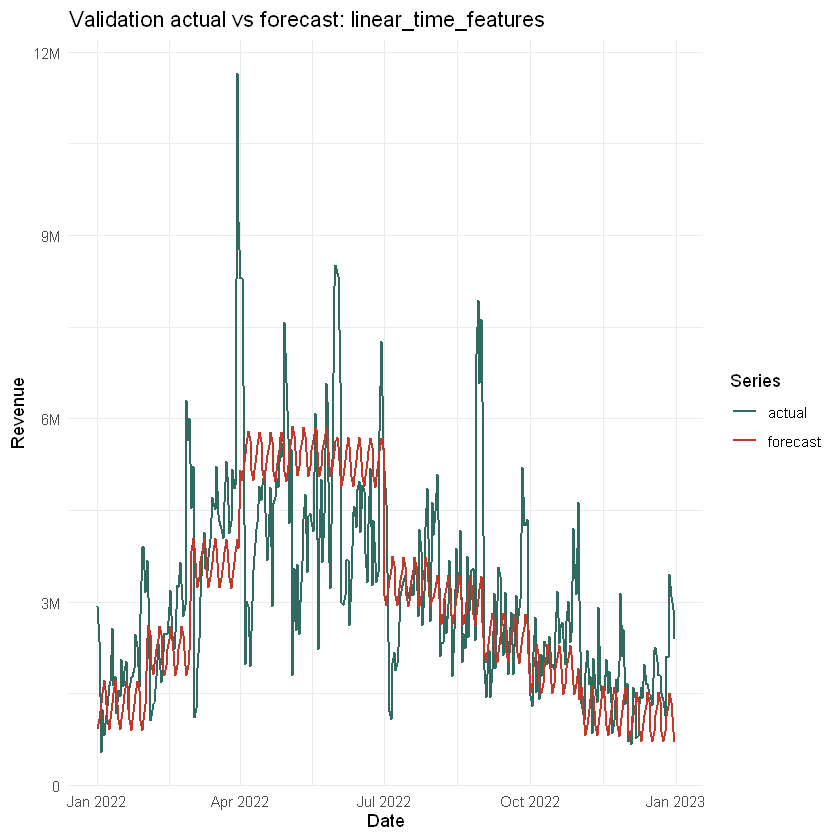

In [10]:
plot_predictions <- baseline_predictions |>
  select(Date, actual, all_of(selected_baseline)) |>
  rename(forecast = all_of(selected_baseline)) |>
  pivot_longer(cols = c(actual, forecast), names_to = "series", values_to = "Revenue")

p_forecast <- ggplot(plot_predictions, aes(x = Date, y = Revenue, color = series)) +
  geom_line(linewidth = 0.65) +
  scale_y_continuous(labels = label_number(scale_cut = cut_short_scale())) +
  scale_color_manual(values = c(actual = "#2F6B5F", forecast = "#C0392B")) +
  labs(
    title = paste("Validation actual vs forecast:", selected_baseline),
    x = "Date",
    y = "Revenue",
    color = "Series"
  )

p_forecast
ggsave(file.path(chart_dir, "baseline_03_actual_vs_forecast.png"), p_forecast, width = 9, height = 5, dpi = 160)


## 9. Residual Summary


In [11]:
validation_residuals <- baseline_predictions |>
  transmute(
    Date,
    actual,
    forecast = .data[[selected_baseline]],
    residual = actual - forecast,
    abs_error = abs(residual),
    pct_error = residual / actual
  )

residual_summary <- validation_residuals |>
  summarise(
    residual_mean = mean(residual, na.rm = TRUE),
    residual_median = median(residual, na.rm = TRUE),
    residual_sd = sd(residual, na.rm = TRUE),
    min_residual = min(residual, na.rm = TRUE),
    max_residual = max(residual, na.rm = TRUE),
    mean_abs_error = mean(abs_error, na.rm = TRUE)
  )

residual_summary


residual_mean,residual_median,residual_sd,min_residual,max_residual,mean_abs_error
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
183388.7,172062.5,1406699,-4073273,7619768,1016413


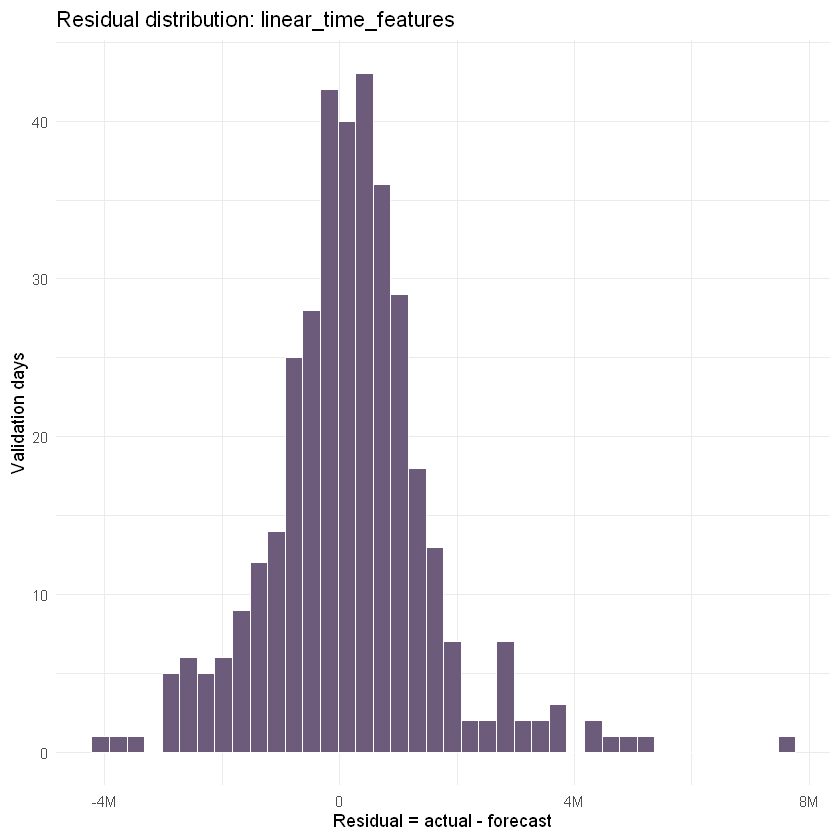

In [12]:
p_residual <- ggplot(validation_residuals, aes(x = residual)) +
  geom_histogram(bins = 40, fill = "#6C5B7B", color = "white") +
  scale_x_continuous(labels = label_number(scale_cut = cut_short_scale())) +
  labs(
    title = paste("Residual distribution:", selected_baseline),
    x = "Residual = actual - forecast",
    y = "Validation days"
  )

p_residual
ggsave(file.path(chart_dir, "baseline_04_residual_distribution.png"), p_residual, width = 8, height = 5, dpi = 160)


## 10. Save Baseline Outputs


In [13]:
validation_predictions_long <- baseline_predictions |>
  pivot_longer(cols = all_of(model_columns), names_to = "model", values_to = "forecast") |>
  mutate(residual = actual - forecast, abs_error = abs(residual))

write.csv(score_table, file.path(artifact_dir, "baseline_score_table.csv"), row.names = FALSE)
write.csv(baseline_predictions, file.path(artifact_dir, "baseline_validation_predictions_wide.csv"), row.names = FALSE)
write.csv(validation_predictions_long, file.path(artifact_dir, "baseline_validation_predictions_long.csv"), row.names = FALSE)
write.csv(validation_residuals, file.path(artifact_dir, "selected_baseline_residuals.csv"), row.names = FALSE)
write.csv(residual_summary, file.path(artifact_dir, "selected_baseline_residual_summary.csv"), row.names = FALSE)

selected_baseline_table <- tibble::tibble(
  selected_baseline = selected_baseline,
  selection_metric = "lowest validation RMSE",
  validation_start = min(valid_data$Date),
  validation_end = max(valid_data$Date)
) |>
  bind_cols(best_model |> select(MAE, RMSE, R2))

write.csv(selected_baseline_table, file.path(artifact_dir, "selected_baseline.csv"), row.names = FALSE)

selected_baseline_table


selected_baseline,selection_metric,validation_start,validation_end,MAE,RMSE,R2
<chr>,<chr>,<date>,<date>,<dbl>,<dbl>,<dbl>
linear_time_features,lowest validation RMSE,2022-01-01,2022-12-31,1016413,1416690,0.2836298


## 11. Baseline Decision For Notebook 06

The selected baseline is the model with the lowest validation RMSE. Notebook 06 should improve on this benchmark with richer but still leakage-safe feature engineering, proper time-series cross-validation, and explainability.

The next notebook should compare every advanced model against:

- the validation score table from this notebook;
- the selected baseline forecast;
- the residual weaknesses observed here.
